# BS1 : Baselines Count & TF-IDF avec Tuning

**Contexte**

Ce notebook constitue le point de départ de la phase de modélisation.
Avant de passer à des approches plus complexes (embeddings, transformers...),
on commence par tester des approches classiques de NLP pour établir une
référence solide.

L'idée est simple : représenter le texte sous forme de vecteurs numériques,
puis entraîner un classifieur sur ces vecteurs pour prédire si un tweet
décrit une vraie catastrophe (target=1) ou non (target=0).

---

**Organisation du notebook**

Ce notebook se découpe en deux phases :

Phase 1 : Baselines : chaque pipeline est entraîné avec ses paramètres
par défaut, sans aucune optimisation. L'objectif est d'avoir une première
idée des performances brutes de chaque approche et d'identifier les
combinaisons vectorisation + classifieur les plus prometteuses.

Phase 2 : Tuning accéléré : plutôt que de relancer tout le pipeline
à chaque essai (ce qui serait coûteux en temps), on vectorise le texte
une seule fois puis on fait varier uniquement les hyperparamètres du
classifieur. C'est un bon compromis entre rigueur et rapidité
d'expérimentation.

---

**Pipelines testés (P1 à P5)**

Cinq pipelines sont testés dans ce notebook, combinant deux types de
vectorisation avec quatre familles de classifieurs :

Vectorisation :
* CountVectorizer : transforme chaque tweet en un vecteur de comptes
  bruts, chaque dimension correspond à un mot du vocabulaire, et la valeur
  est le nombre de fois que ce mot apparaît dans le tweet
* TfidfVectorizer : même principe, mais pondère chaque compte par
  l'importance relative du mot dans le corpus, les mots rares et
  informatifs reçoivent un score plus élevé que les mots très fréquents

Classifieurs :
* Naive Bayes (MultinomialNB) : modèle probabiliste qui calcule la
  probabilité qu'un tweet appartienne à chaque classe étant donné les mots
  qu'il contient. Simple, rapide, et souvent efficace en NLP.
* Régression Logistique : modèle linéaire qui apprend un poids pour
  chaque mot du vocabulaire, puis combine ces poids pour prédire la classe.
  Très compétitif en NLP avec TF-IDF.
* LinearSVC : SVM linéaire qui cherche la frontière de décision qui
  maximise la marge entre les deux classes dans l'espace TF-IDF.
  Souvent le meilleur modèle classique en classification de texte.
* SGDClassifier : même principe que la régression logistique mais
  entraîné par descente de gradient stochastique, plus rapide sur de
  grands datasets.

---

**Métriques d'évaluation**

Vu le déséquilibre modéré du dataset (81,4% non-disaster contre 18,6% disaster), un modèle qui prédit toujours "non-disaster" obtiendrait déjà 81% d'accuracy sans rien apprendre. On se concentre donc sur :

* F1-score (métrique principale) : équilibre entre précision
  et rappel sur la classe disaster, c'est la métrique qui compte vraiment
* Recall : parmi tous les vrais tweets disaster, combien
  notre modèle en détecte ? Un recall faible signifie qu'on rate beaucoup
  de vrais disasters.
* Precision : parmi tous les tweets prédits disaster, combien
  le sont vraiment ? Une précision faible signifie beaucoup de faux positifs.
* Balanced accuracy : moyenne du recall sur chaque classe, robuste
  face au déséquilibre
* ROC-AUC et PR-AUC : métriques globales de discrimination

**Résultats attendus**

À la fin de ce notebook, un **tableau comparatif** de tous les modèles
testés sera produit, permettant d'identifier la meilleure combinaison
vectorisation + classifieur. Cette combinaison sera ensuite comparée
aux approches ensemblistes et deep learning
dans le tableau comparatif global (autre notebook).

# 1. Importations et chargement des fichiers csv test et train

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd                      # manipulation des données tabulaires
import numpy as np                       # calcul numérique
import matplotlib.pyplot as plt          # visualisation
import seaborn as sns                    # visualisation statistique
import json                              # sérialisation des paramètres
from collections import OrderedDict      # dictionnaire ordonné pour les pipelines

from sklearn.pipeline import Pipeline                          # enchaînement vectoriseur + classifieur
from sklearn.feature_extraction.text import (
    CountVectorizer,                                           # comptage brut des occurrences de mots
    TfidfVectorizer                                            # pondération TF-IDF des mots
)
from sklearn.naive_bayes import MultinomialNB                  # Naive Bayes pour données de comptage
from sklearn.linear_model import LogisticRegression, SGDClassifier  # modèles linéaires
from sklearn.svm import LinearSVC                              # SVM linéaire

from sklearn.model_selection import GridSearchCV, StratifiedKFold  
# GridSearchCV : recherche des meilleurs hyperparamètres par validation croisée
# StratifiedKFold : K-Fold stratifié (conserve les proportions des classes dans chaque fold)
from sklearn.metrics import (
    f1_score,           # F1-score : équilibre précision/rappel
    accuracy_score,     # proportion de prédictions correctes
    precision_score,    # parmi les prédits positifs, combien le sont vraiment
    recall_score,       # parmi les vrais positifs, combien sont détectés
    balanced_accuracy_score,  # moyenne du recall par classe
    roc_auc_score,      # aire sous la courbe ROC
    classification_report,    # rapport complet par classe
    confusion_matrix          # matrice de confusion
)

from sklearn.model_selection import StratifiedShuffleSplit     # split stratifié pour le tuning

import warnings
warnings.filterwarnings('ignore')

print('✅ Imports effectués avec succès')

✅ Imports effectués avec succès


In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TEXT_COL     = 'text_lemma'   # colonne de texte utilisée pour la vectorisation
LABEL_COL    = 'target'       # variable cible (0 = non-disaster, 1 = disaster)
RANDOM_STATE = 42             # graine aléatoire pour la reproductibilité

FEATURES_NUM = [              # features numériques complémentaires
    'word_count', 'mean_word_length', 'lexical_diversity',
    'stop_word_count', 'url_count', 'punctuation_count',
    'hashtag_count', 'keyword_disaster_rate'
]

# ── CHARGEMENT DES DONNÉES ────────────────────────────────────────────────────
# Chargement des datasets nettoyés depuis le notebook EDA
#**Note :** Ce notebook a été développé sur Kaggle. 
# Pour l'exécuter localement, remplacez les chemins 
# `/kaggle/input/notebooks/aissatousamb/eda-tweets/` 
# par le chemin local vers vos fichiers CSV grace a ce bloc de code:
# import os
# Afficher tous les fichiers disponibles en input — les chemins de train_cleaned.csv 
# et test_cleaned.csv sont à copier dans le chemin d'accès de pd.read_csv()
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
    #      print(os.path.join(dirname, filename))
train = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/test_cleaned.csv')

# Définition de X et y
X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]
y_train = train[LABEL_COL]
y_test  = test[LABEL_COL]

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")
print(f"\nDistribution des classes - train :")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nDistribution des classes - test :")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Taille train : 8979
Taille test  : 2245

Distribution des classes - train :
target
0    0.815
1    0.185
Name: proportion, dtype: float64

Distribution des classes - test :
target
0    0.815
1    0.185
Name: proportion, dtype: float64


# 2. Définition des pipelines

On définit ici les 5 pipelines qui seront comparés dans ce notebook.
Chaque pipeline combine un vectoriseur et un classifieur dans un objet
`Pipeline` sklearn qui enchaîne les deux étapes automatiquement :

1. Le vectoriseur transforme le texte en vecteur numérique
2. Le classifieur apprend à partir de ces vecteurs pour prédire la classe

**Paramètres communs aux vectoriseurs :**
* `min_df=2` : ignore les mots apparaissant dans moins de 2 tweets
  (trop rares, probablement du bruit)
* `max_df=0.95` : ignore les mots apparaissant dans plus de 95% des tweets
  (trop fréquents, pas informatifs)
* `ngram_range=(1,2)` : considère les mots seuls (unigrammes) et les paires
  de mots consécutifs (bigrammes) ce qui capture des expressions comme
  "mass murder", "breaking news", "body bag"
* `sublinear_tf=True` : applique log(TF) au lieu de TF brut, ce qui atténue
  l'effet des mots très répétés

In [3]:
# ── DÉFINITION DES PIPELINES ──────────────────────────────────────────────────
pipelines = OrderedDict({

    # P01 : Baseline minimale — CountVectorizer + Naive Bayes
    # La combinaison la plus classique en NLP. CountVectorizer compte les mots,
    # MultinomialNB calcule la probabilité de chaque classe. Simple mais efficace.
    "P01_Count_MultinomialNB": Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,1), min_df=2)),
        ("clf",  MultinomialNB(alpha=0.5)),
    ]),

    # P02 : TF-IDF unigrammes + Régression Logistique
    # On pondère les mots par leur importance (TF-IDF) et on classifie
    # de façon linéaire. Baseline forte, souvent difficile à battre.
    "P02_TFIDF_Unigram_LogReg": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,1), min_df=2, max_df=0.95)),
        ("clf",  LogisticRegression(max_iter=2000, C=1.0)),
    ]),

    # P03 : TF-IDF unigrammes + bigrammes + Régression Logistique
    # Même approche que P02, mais on enrichit la représentation avec des
    # paires de mots consécutifs pour capturer des expressions importantes.
    "P03_TFIDF_UniBi_LogReg": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
        ("clf",  LogisticRegression(max_iter=2500, C=1.0)),
    ]),

    # P04 : TF-IDF unigrammes + bigrammes + LinearSVC
    # SVM linéaire — cherche la frontière qui maximise la marge entre les
    # deux classes. Très efficace sur les espaces TF-IDF de haute dimension.
    "P04_TFIDF_UniBi_LinearSVC": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
        ("clf",  LinearSVC(C=1.0)),
    ]),

    # P05 : TF-IDF unigrammes + bigrammes + SGD (log_loss)
    # Équivalent à une régression logistique entraînée par descente de
    # gradient stochastique — plus rapide sur de grands datasets.
    "P05_TFIDF_UniBi_SGDLog": Pipeline([
        ("vect", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
        ("clf",  SGDClassifier(loss='log_loss', penalty='l2',
                               alpha=1e-5, max_iter=3000, random_state=42)),
    ]),
})

print(f"✅ {len(pipelines)} pipelines définis")
for name in pipelines:
    print(f"   → {name}")

✅ 5 pipelines définis
   → P01_Count_MultinomialNB
   → P02_TFIDF_Unigram_LogReg
   → P03_TFIDF_UniBi_LogReg
   → P04_TFIDF_UniBi_LinearSVC
   → P05_TFIDF_UniBi_SGDLog


## 2.1. Phase 1 : Baselines sans optimisation

On entraîne ici chaque pipeline avec ses paramètres par défaut, sans
aucune optimisation. Pour chaque pipeline :

1. `pipeline.fit(X_train, y_train)` : entraîne le vectoriseur ET le
   classifieur sur le train set
2. `pipeline.predict(X_test)` : prédit les classes sur le test set
3. On calcule les métriques d'évaluation

L'objectif de cette phase est d'identifier rapidement quels pipelines
sont prometteurs avant d'investir du temps dans l'optimisation.

**Important :** on surveille particulièrement le **F1-score de la classe 1**
(disaster) plutôt que l'accuracy globale, car un modèle naïf qui prédit
toujours "non-disaster" obtiendrait déjà 81% d'accuracy sans rien apprendre.

In [4]:
# Vérification
print(f"NaN dans text_lemma - train : {train['text_lemma'].isnull().sum()}")
print(f"NaN dans text_lemma - test  : {test['text_lemma'].isnull().sum()}")

NaN dans text_lemma - train : 5
NaN dans text_lemma - test  : 1


In [5]:
# Afficher les tweets qui ont donné un NaN dans text_lemma
nan_mask = train['text_lemma'].isnull()
print(f"Nombre de NaN : {nan_mask.sum()}")
print("\nTweeets originaux correspondants :")
train[nan_mask][['text', 'text_clean', 'text_lemma']].head(10)

Nombre de NaN : 5

Tweeets originaux correspondants :


,text,text_clean,text_lemma
3990,… https://t.co/6vsh3kdagn,NaN,NaN
6404,ㅋ ㅋ ㅋ ㅋ 개웃기네 환상체야,NaN,NaN
6771,https://t.co/umnjj85cjp,NaN,NaN
7642,https://t.co/sssi9yucq4,NaN,NaN
8120,"""ɪ ᴡɪꜱʜ ʏᴏᴜʀ ʟᴜᴄᴋ."" ɪ ꜱᴀɴɢ, ᴜɴᴅᴇʀ ᴛʜᴇ ʙᴀɴɴᴇʀ ᴏ...",NaN,NaN


5 tweets présentent un text_lemma vide après nettoyage (tweets contenant
uniquement une URL, du texte en langue non latine, ou des caractères
d'encodage corrompus). Ces tweets ont été conservés avec une chaîne vide,
produisant un vecteur TF-IDF nul lors de la vectorisation.

In [6]:
# Remplacement des NaN dans text_lemma par une chaîne vide
train['text_lemma'] = train['text_lemma'].fillna('')
test['text_lemma']  = test['text_lemma'].fillna('')

# Vérification
print(f"NaN dans text_lemma - train : {train['text_lemma'].isnull().sum()}")
print(f"NaN dans text_lemma - test  : {test['text_lemma'].isnull().sum()}")

# Redéfinir X_train et X_test
X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]

NaN dans text_lemma - train : 0
NaN dans text_lemma - test  : 0


In [7]:
# ── PHASE 1 : BASELINES ───────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — BASELINES SANS OPTIMISATION")
print("=" * 70)

baseline_results = []

for name, pipeline in pipelines.items():
    print(f"\n→ Entraînement : {name}")

    # Entraînement du pipeline complet (vectoriseur + classifieur)
    pipeline.fit(X_train, y_train)

    # Prédictions sur train et test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # Calcul des métriques
    baseline_results.append({
        'pipeline'          : name,
        'train_accuracy'    : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'  : f1_score(y_train, y_pred_train),
        'train_recall_class_1' : recall_score(y_train, y_pred_train),
        'train_precision_class_1' : precision_score(y_train, y_pred_train),
        'test_accuracy'     : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'   : f1_score(y_test, y_pred_test),
        'test_recall_class_1'  : recall_score(y_test, y_pred_test),
        'test_precision_class_1' : precision_score(y_test, y_pred_test),
        'test_f1_macro'     : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy' : balanced_accuracy_score(y_test, y_pred_test),
    })

    print(f"   ✅ F1 classe 1 : {f1_score(y_test, y_pred_test):.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f}")

# Tableau comparatif baseline
baseline_df = pd.DataFrame(baseline_results).round(3)
baseline_df = baseline_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Baseline ===")
display(baseline_df)

PHASE 1 — BASELINES SANS OPTIMISATION

→ Entraînement : P01_Count_MultinomialNB
   ✅ F1 classe 1 : 0.672 | Recall : 0.708 | Accuracy : 0.872

→ Entraînement : P02_TFIDF_Unigram_LogReg
   ✅ F1 classe 1 : 0.548 | Recall : 0.410 | Accuracy : 0.875

→ Entraînement : P03_TFIDF_UniBi_LogReg
   ✅ F1 classe 1 : 0.531 | Recall : 0.381 | Accuracy : 0.876

→ Entraînement : P04_TFIDF_UniBi_LinearSVC
   ✅ F1 classe 1 : 0.699 | Recall : 0.639 | Accuracy : 0.898

→ Entraînement : P05_TFIDF_UniBi_SGDLog
   ✅ F1 classe 1 : 0.688 | Recall : 0.619 | Accuracy : 0.896

=== Tableau comparatif — Phase Baseline ===


,pipeline,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
3,P04_TFIDF_UniBi_LinearSVC,0.994,0.984,0.972,0.996,0.898,0.699,0.639,0.773,0.819,0.798
4,P05_TFIDF_UniBi_SGDLog,0.995,0.985,0.975,0.996,0.896,0.688,0.619,0.774,0.813,0.789
0,P01_Count_MultinomialNB,0.923,0.798,0.824,0.773,0.872,0.672,0.708,0.639,0.796,0.809
1,P02_TFIDF_Unigram_LogReg,0.904,0.662,0.507,0.953,0.875,0.548,0.410,0.829,0.738,0.695
2,P03_TFIDF_UniBi_LogReg,0.902,0.641,0.476,0.981,0.876,0.531,0.381,0.878,0.730,0.684


## 2.2. Visualisation des résultats baseline

On visualise ici les métriques clés pour comparer les 5 pipelines.
Le graphique met en évidence le **F1-score de la classe 1** (disaster)
et le **recall** , les deux métriques les plus importantes vu le
déséquilibre du dataset.

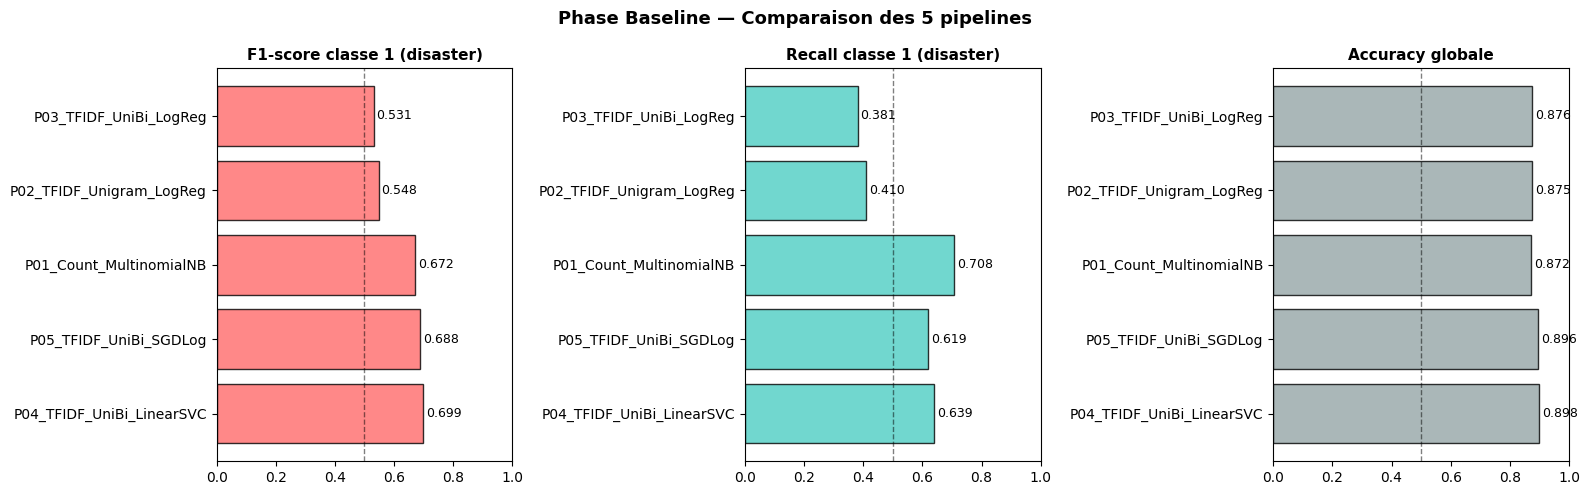

In [8]:
# ── VISUALISATION BASELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_f1_class_1', 'test_recall_class_1', 'test_accuracy']
titles  = ['F1-score classe 1 (disaster)', 'Recall classe 1 (disaster)', 'Accuracy globale']
colors  = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.barh(baseline_df['pipeline'], baseline_df[metric],
                   color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
    for bar, val in zip(bars, baseline_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase Baseline — Comparaison des 5 pipelines', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3. Phase 2 : Tuning avec GridSearchCV et K-Fold Stratifié

Pour trouver les meilleurs hyperparamètres de chaque classifieur, on
utilise `GridSearchCV` de sklearn , l'outil standard pour la recherche
d'hyperparamètres.

**Ce que fait GridSearchCV :**
1. Pour chaque combinaison d'hyperparamètres dans la grille :
   - Divise X_train en 5 folds stratifiés (Stratified K-Fold)
   - Entraîne le pipeline sur 4 folds → évalue sur le 5ème
   - Répète 5 fois (chaque fold sert une fois de validation)
   - Calcule le F1 moyen sur les 5 évaluations
2. Garde la combinaison qui maximise le F1 classe 1
3. Ré-entraîne automatiquement le meilleur modèle sur tout X_train

**Pourquoi K-Fold plutôt qu'un simple split ?**
Un simple split (85%/15%) donne un seul score de validation — sensible
au hasard du découpage. Le K-Fold donne une moyenne sur 5 évaluations
différentes, ce qui est beaucoup plus fiable et robuste.

**Le préfixe clf__ dans les paramètres :**
Dans un pipeline sklearn, chaque étape a un nom ('vect', 'clf').
Pour cibler les hyperparamètres du classifieur uniquement, on préfixe
les paramètres avec 'clf__' (ex: 'clf__C' pour le paramètre C
de la Régression Logistique).

In [9]:
# ── PHASE 2 : TUNING AVEC GRIDSEARCHCV + K-FOLD ──────────────────────────────
print("=" * 70)
print("PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)")
print("=" * 70)

# Validation croisée stratifiée en 5 folds
# Stratifié = chaque fold conserve les proportions 81/19 disaster/non-disaster
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Grilles d'hyperparamètres avec préfixe 'clf__' pour cibler le classifieur
# dans le pipeline (sklearn exige ce préfixe pour distinguer les étapes)
param_grids = {
    # alpha : paramètre de lissage de Naive Bayes
    "P01_Count_MultinomialNB": {
        "clf__alpha": [0.1, 0.5, 1.0, 2.0]
    },

    # C : force de régularisation (faible = simple, élevé = complexe)
    # class_weight : balanced = compense le déséquilibre 81/19
    "P02_TFIDF_Unigram_LogReg": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },

    "P03_TFIDF_UniBi_LogReg": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },

    "P04_TFIDF_UniBi_LinearSVC": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },

    "P05_TFIDF_UniBi_SGDLog": {
        "clf__alpha"       : [1e-6, 1e-5, 1e-4],
        "clf__penalty"     : ["l2", "elasticnet"],
        "clf__class_weight": [None, "balanced"]
    },
}

tuned_results = []

for name, pipeline in pipelines.items():
    print(f"\n{'='*70}")
    print(f"Tuning → {name}")

    param_grid = param_grids.get(name)
    if param_grid is None:
        print("Aucune grille définie — pipeline ignoré")
        continue

    # GridSearchCV :
    # - teste toutes les combinaisons de param_grid
    # - pour chaque combinaison, fait un 5-Fold stratifié
    # - garde la combinaison qui maximise le F1 classe 1
    grid_search = GridSearchCV(
        estimator  = pipeline,    # pipeline complet (vectoriseur + classifieur)
        param_grid = param_grid,  # combinaisons à tester
        cv         = cv,          # 5-Fold stratifié
        scoring    = 'f1',        # métrique : F1 classe 1 (disaster)
        n_jobs     = -1,          # parallélisation sur tous les CPUs
        verbose    = 1            # affiche la progression
    )

    # Entraînement : teste toutes les combinaisons sur X_train
    grid_search.fit(X_train, y_train)

    print(f"   Meilleurs paramètres : {grid_search.best_params_}")
    print(f"   Meilleur F1 (CV)     : {grid_search.best_score_:.3f}")

    # Prédictions avec le meilleur modèle (déjà ré-entraîné sur tout X_train)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test  = grid_search.predict(X_test)

    tuned_results.append({
        'pipeline'               : name,
        'best_params'            : json.dumps(grid_search.best_params_),
        'best_cv_f1_class_1'     : grid_search.best_score_,
        'train_accuracy'         : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'       : f1_score(y_train, y_pred_train),
        'train_recall_class_1'   : recall_score(y_train, y_pred_train),
        'train_precision_class_1': precision_score(y_train, y_pred_train),
        'test_accuracy'          : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'        : f1_score(y_test, y_pred_test),
        'test_recall_class_1'    : recall_score(y_test, y_pred_test),
        'test_precision_class_1' : precision_score(y_test, y_pred_test),
        'test_f1_macro'          : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy' : balanced_accuracy_score(y_test, y_pred_test),
    })

    print(f"   ✅ Test F1 classe 1 : {f1_score(y_test, y_pred_test):.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f}")

# Tableau comparatif tuning
tuned_df = pd.DataFrame(tuned_results).round(3)
tuned_df = tuned_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Tuning (GridSearchCV) ===")
display(tuned_df)

PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)

Tuning → P01_Count_MultinomialNB
Fitting 5 folds for each of 4 candidates, totalling 20 fits
   Meilleurs paramètres : {'clf__alpha': 0.1}
   Meilleur F1 (CV)     : 0.677
   ✅ Test F1 classe 1 : 0.682 | Recall : 0.696 | Accuracy : 0.880

Tuning → P02_TFIDF_Unigram_LogReg
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 4.0, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.669
   ✅ Test F1 classe 1 : 0.667 | Recall : 0.766 | Accuracy : 0.859

Tuning → P03_TFIDF_UniBi_LogReg
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 4.0, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.685
   ✅ Test F1 classe 1 : 0.710 | Recall : 0.771 | Accuracy : 0.883

Tuning → P04_TFIDF_UniBi_LinearSVC
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 1.0, 'clf__class_weight': 'balanced'}


,pipeline,best_params,best_cv_f1_class_1,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
2,P03_TFIDF_UniBi_LogReg,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}",0.685,0.977,0.941,0.996,0.892,0.883,0.710,0.771,0.657,0.818,0.840
3,P04_TFIDF_UniBi_LinearSVC,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}",0.688,0.993,0.982,0.999,0.964,0.885,0.701,0.730,0.673,0.815,0.825
4,P05_TFIDF_UniBi_SGDLog,"{""clf__alpha"": 1e-05, ""clf__class_weight"": nul...",0.683,0.995,0.985,0.975,0.996,0.896,0.688,0.619,0.774,0.813,0.789
0,P01_Count_MultinomialNB,"{""clf__alpha"": 0.1}",0.677,0.939,0.838,0.853,0.822,0.880,0.682,0.696,0.669,0.804,0.809
1,P02_TFIDF_Unigram_LogReg,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}",0.669,0.955,0.888,0.976,0.815,0.859,0.667,0.766,0.591,0.789,0.823


### Grilles d'hyperparamètres

On définit ici les hyperparamètres à tester pour chaque classifieur.
Pour chaque combinaison possible, on entraîne le classifieur sur `X_fit`
vectorisé et on évalue sur `X_val` vectorisé, le tout sur la même
matrice de features déjà calculée (d'où le nom "tuning accéléré").

In [10]:
# ── GRILLES D'HYPERPARAMÈTRES ─────────────────────────────────────────────────
# Pour chaque pipeline, on définit les valeurs d'hyperparamètres à tester
# sur le classifieur uniquement (le vectoriseur est fixé)

param_grids = {
    # Naive Bayes : on fait varier alpha (lissage)
    # alpha faible → plus sensible aux données
    # alpha élevé  → plus prudent/régularisé
    "P01_Count_MultinomialNB": {
        "alpha": [0.1, 0.5, 1.0, 2.0]
    },

    # LogReg unigrammes : on varie C (régularisation) et class_weight
    # C faible    → modèle plus simple, moins d'overfitting
    # C élevé     → modèle plus complexe, peut overfit
    # balanced    → compense automatiquement le déséquilibre 81/19
    "P02_TFIDF_Unigram_LogReg": {
        "C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "class_weight": [None, "balanced"]
    },

    # LogReg bigrammes : mêmes hyperparamètres que P02
    "P03_TFIDF_UniBi_LogReg": {
        "C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "class_weight": [None, "balanced"]
    },

    # LinearSVC : même logique que LogReg
    "P04_TFIDF_UniBi_LinearSVC": {
        "C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "class_weight": [None, "balanced"]
    },

    # SGD : en plus de C et class_weight, on teste deux types de régularisation
    # l2          → Ridge (pénalise les grands poids)
    # elasticnet  → combinaison L1 + L2 (peut mettre certains poids à zéro)
    "P05_TFIDF_UniBi_SGDLog": {
        "alpha"       : [1e-6, 1e-5, 1e-4],
        "penalty"     : ["l2", "elasticnet"],
        "class_weight": [None, "balanced"]
    },
}

print("✅ Grilles d'hyperparamètres définies")
for name, grid in param_grids.items():
    n_combinations = 1
    for values in grid.values():
        n_combinations *= len(values)
    print(f"   → {name} : {n_combinations} combinaisons à tester")

✅ Grilles d'hyperparamètres définies
   → P01_Count_MultinomialNB : 4 combinaisons à tester
   → P02_TFIDF_Unigram_LogReg : 10 combinaisons à tester
   → P03_TFIDF_UniBi_LogReg : 10 combinaisons à tester
   → P04_TFIDF_UniBi_LinearSVC : 10 combinaisons à tester
   → P05_TFIDF_UniBi_SGDLog : 12 combinaisons à tester


## 2.4. Comparaison Baseline vs Tuning

On compare ici les performances avant et après tuning pour mesurer
l'apport de l'optimisation des hyperparamètres. Le delta (différence)
sur le F1 classe 1 montre combien chaque pipeline a progressé grâce
au tuning.

Un delta positif élevé signifie que le pipeline était sous-optimal
avec ses paramètres par défaut et que le tuning a apporté une
amélioration significative.

=== Comparaison Baseline vs Tuning ===


,pipeline,baseline_f1_class_1,tuned_f1_class_1,delta_f1_class_1,baseline_recall,tuned_recall,delta_recall,best_params
4,P03_TFIDF_UniBi_LogReg,0.531,0.710,0.179,0.381,0.771,0.390,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}"
3,P02_TFIDF_Unigram_LogReg,0.548,0.667,0.119,0.410,0.766,0.356,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}"
2,P01_Count_MultinomialNB,0.672,0.682,0.010,0.708,0.696,-0.012,"{""clf__alpha"": 0.1}"
0,P04_TFIDF_UniBi_LinearSVC,0.699,0.701,0.002,0.639,0.730,0.091,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}"
1,P05_TFIDF_UniBi_SGDLog,0.688,0.688,0.000,0.619,0.619,0.000,"{""clf__alpha"": 1e-05, ""clf__class_weight"": nul..."


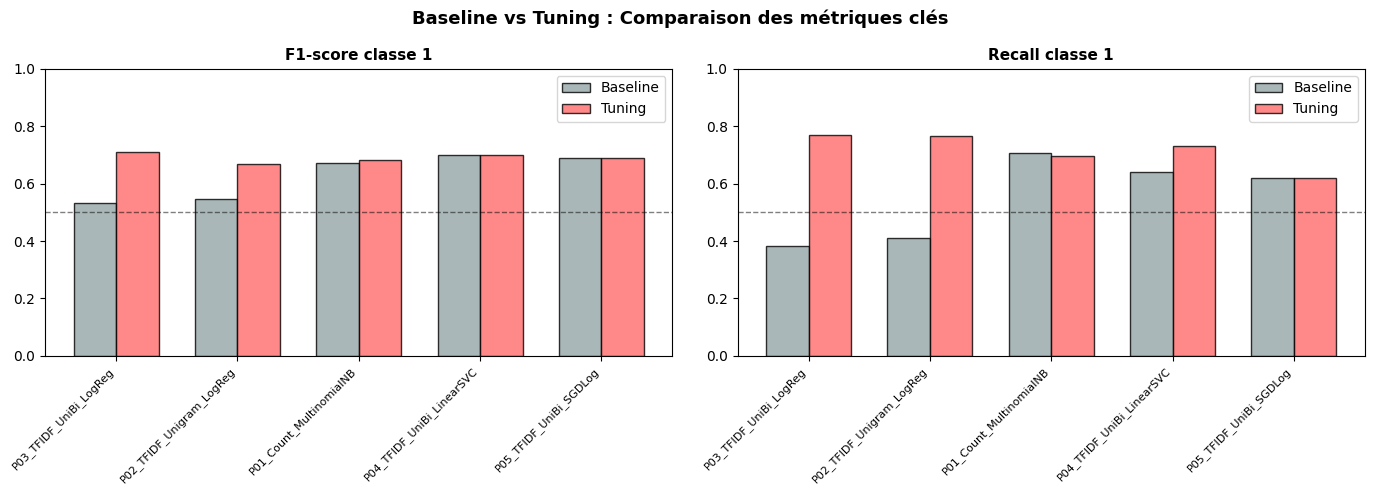

In [11]:
# ── COMPARAISON BASELINE VS TUNING ───────────────────────────────────────────
comparison = []

for _, baseline_row in baseline_df.iterrows():
    tuned_row = tuned_df[tuned_df['pipeline'] == baseline_row['pipeline']].iloc[0]
    comparison.append({
        'pipeline'              : baseline_row['pipeline'],
        'baseline_f1_class_1'  : baseline_row['test_f1_class_1'],
        'tuned_f1_class_1'     : tuned_row['test_f1_class_1'],
        'delta_f1_class_1'     : tuned_row['test_f1_class_1'] - baseline_row['test_f1_class_1'],
        'baseline_recall'      : baseline_row['test_recall_class_1'],
        'tuned_recall'         : tuned_row['test_recall_class_1'],
        'delta_recall'         : tuned_row['test_recall_class_1'] - baseline_row['test_recall_class_1'],
        'best_params'          : tuned_row['best_params'],
    })

comparison_df = pd.DataFrame(comparison).round(3)
comparison_df = comparison_df.sort_values('delta_f1_class_1', ascending=False)

print("=== Comparaison Baseline vs Tuning ===")
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(comparison_df))
width = 0.35

for ax, metric_base, metric_tuned, title in zip(
    axes,
    ['baseline_f1_class_1', 'baseline_recall'],
    ['tuned_f1_class_1', 'tuned_recall'],
    ['F1-score classe 1', 'Recall classe 1']
):
    ax.bar([i - width/2 for i in x], comparison_df[metric_base],
           width, label='Baseline', color='#95A5A6', edgecolor='black', alpha=0.8)
    ax.bar([i + width/2 for i in x], comparison_df[metric_tuned],
           width, label='Tuning', color='#FF6B6B', edgecolor='black', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df['pipeline'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Baseline vs Tuning : Comparaison des métriques clés',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Sauvegarde des résultats

On sauvegarde ici les résultats de ce notebook (baseline + tuning)
pour pouvoir les comparer avec les autres notebooks dans le tableau
comparatif global (NB_Comparaison).

In [12]:
# ── SAUVEGARDE DES RÉSULTATS ──────────────────────────────────────────────────
baseline_df.to_csv('/kaggle/working/NB1_baseline_results.csv', index=False)
tuned_df.to_csv('/kaggle/working/NB1_tuned_results.csv', index=False)
comparison_df.to_csv('/kaggle/working/NB1_comparison_results.csv', index=False)

print("✅ Résultats sauvegardés :")
print("   → /kaggle/working/NB1_baseline_results.csv")
print("   → /kaggle/working/NB1_tuned_results.csv")
print("   → /kaggle/working/NB1_comparison_results.csv")
print(f"\nMeilleur pipeline (tuning) : {tuned_df.iloc[0]['pipeline']}")
print(f"F1 classe 1 : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
print(f"Recall classe 1 : {tuned_df.iloc[0]['test_recall_class_1']:.3f}")
print(f"Meilleurs paramètres : {tuned_df.iloc[0]['best_params']}")

✅ Résultats sauvegardés :
   → /kaggle/working/NB1_baseline_results.csv
   → /kaggle/working/NB1_tuned_results.csv
   → /kaggle/working/NB1_comparison_results.csv

Meilleur pipeline (tuning) : P03_TFIDF_UniBi_LogReg
F1 classe 1 : 0.710
Recall classe 1 : 0.771
Meilleurs paramètres : {"clf__C": 4.0, "clf__class_weight": "balanced"}
